In [65]:
import os, re, random, json
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

import matplotlib.pyplot as plt

# ==============================
# paths
# ==============================
OPERATING_XLSX   = "./output/Decision_variablesRU.xlsx"  # targets g-MM-YYYY
GAS_IND_XLSX     = "./input/Gas Cons Ind.xlsx"           # inputs gas
GAS_EXP_XLSX     = "./input/Gas Cons Export.xlsx"        # inputs gas
GAS_DIST_XLSX    = "./input/Gas Cons Distrib.xlsx"       # inputs gas
GAS_NETWORK_XLSX = "./Gas Network Data.xlsx"       # optional static

# ==============================
# day-ahead setup
# ==============================
HIST_HOURS = 72
HORIZON_HOURS = 24
STRIDE = 1              # stride=1 for training windows, stride=24 for operational style evaluation
USE_STATIC = False      # set True if you want to add static_vec to every x

# ==============================
# train setup (editable)
# ==============================
SEED = 42
BATCH_SIZE = 24 #64
EPOCHS = 500
LR = 1e-3 #1e-4
DROPOUT = 0.4 #0.15
HIDDEN_SIZES = [512, 512, 256] #1024 1024 512
PATIENCE = 25

# scheduler (editable)
USE_SCHEDULER = True
SCHED_FACTOR = 0.8
SCHED_PATIENCE = 7
MIN_LR = 1e-6

# split time (editable)
SPLIT_TS = "2024-10-01 00:00:00"

# output dir
OUT_DIR = "./runs_mlp_gas_only"
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


In [66]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("seed set to", SEED)

# keep only numerical values (float/int)
def clean_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    drop_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    df = df.drop(columns=drop_cols, errors="ignore")
    df = df.select_dtypes(include=[np.number])
    return df

def has_nan(arr: np.ndarray) -> bool:
    return np.isnan(arr).any()

def has_inf(arr: np.ndarray) -> bool:
    return np.isinf(arr).any()

def rmse_flat(y_true_flat, y_pred_flat) -> float:
    return float(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))

TIME_CANDIDATES = ["Date Time", "Datetime", "date time", "datetime", "DateTime", "DATE TIME", "DATETIME", "timestamp", "Timestamp", "TIME", "Time"]

def extract_datetime_and_numeric(df: pd.DataFrame):
    time_col = None
    for c in df.columns:
        if str(c) in TIME_CANDIDATES:
            time_col = c
            break
    if time_col is None:
        num = df.select_dtypes(include=[np.number]).copy()
        return None, num
    dt = pd.to_datetime(df[time_col], errors="coerce")
    num = df.drop(columns=[time_col], errors="ignore").select_dtypes(include=[np.number]).copy()
    return dt, num

seed set to 42


In [67]:
def list_months_in_operating_excel_g(xlsx_path: str) -> List[Tuple[str, str]]:
    xls = pd.ExcelFile(xlsx_path)
    sheets = [s.strip() for s in xls.sheet_names]
    pattern = re.compile(r"^g-(\d{2})-(\d{4})$")  # only g-MM-YYYY
    months_ok = []
    for s in sheets:
        m = pattern.match(s)
        if m:
            mo, yr = m.group(1), m.group(2)
            months_ok.append((mo, yr))
    months_ok = sorted(months_ok, key=lambda x: (x[1], x[0]))
    return months_ok

def inspect_operating_g(xlsx_path: str, n_preview: int = 2):
    xls = pd.ExcelFile(xlsx_path)
    months_ok = list_months_in_operating_excel_g(xlsx_path)
    print("nb sheets:", len(xls.sheet_names))
    print("g months:", months_ok)

    if len(months_ok) == 0:
        raise ValueError("no g-MM-YYYY sheets found")

    # preview first month
    mo, yr = months_ok[0]
    sh = f"g-{mo}-{yr}"
    raw = pd.read_excel(xlsx_path, sheet_name=sh)
    print("sample sheet:", sh, "| raw shape:", raw.shape)
    print("raw columns:", raw.columns.tolist())
    print("raw dtypes head:\n", raw.dtypes.head(10))
    print(raw.head(n_preview))
    return months_ok

months_available = inspect_operating_g(OPERATING_XLSX)

nb sheets: 72
g months: [('01', '2024'), ('02', '2024'), ('03', '2024'), ('04', '2024'), ('05', '2024'), ('06', '2024'), ('07', '2024'), ('08', '2024'), ('09', '2024'), ('10', '2024'), ('11', '2024'), ('12', '2024')]
sample sheet: g-01-2024 | raw shape: (744, 5)
raw columns: ['Unnamed: 0', 0, 1, 2, 3]
raw dtypes head:
 Unnamed: 0      int64
0             float64
1             float64
2             float64
3             float64
dtype: object
   Unnamed: 0         0         1         2         3
0           0  2.163437  0.344229  1.371083  0.078159
1           1  2.394095  0.444444  1.333333  0.228159


In [68]:
def read_month_sheet_g(xls: pd.ExcelFile, sheet: str) -> pd.DataFrame:
    df = pd.read_excel(xls, sheet_name=sheet)
    df = clean_numeric_df(df)
    return df

def load_targets_g_long(operating_xlsx_path: str,
                        months_to_load: List[Tuple[str,str]]) -> pd.DataFrame:
    """
    df_long contains:
    - g_* columns (G wells/imports)
    - year, month, t (hour in the month: 0..n-1)
    """
    xls = pd.ExcelFile(operating_xlsx_path)
    all_rows = []

    for (mo, yr) in months_to_load:
        sh_g = f"g-{mo}-{yr}"
        g = read_month_sheet_g(xls, sh_g)

        # keep only numeric cols, no invention
        g = g.select_dtypes(include=[np.number])
        n = len(g)

        df = g.add_prefix("g_").copy()
        df["month"] = mo
        df["year"]  = yr
        df["t"]     = np.arange(n)
        all_rows.append(df)

    df_long = pd.concat(all_rows, ignore_index=True)
    return df_long

def make_continuous_ts_from_year_month_t(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    df2["year_i"] = df2["year"].astype(int)
    df2["month_i"] = df2["month"].astype(int)
    start = pd.to_datetime(df2["year_i"].astype(str) + "-" + df2["month_i"].astype(str).str.zfill(2) + "-01 00:00:00")
    df2["ts"] = start + pd.to_timedelta(df2["t"].astype(int), unit="h")
    df2 = df2.sort_values("ts").reset_index(drop=True)
    return df2

df_g_long = load_targets_g_long(OPERATING_XLSX, months_available)
df_g_all = make_continuous_ts_from_year_month_t(df_g_long)

G = sum(str(c).startswith("g_") for c in df_g_all.columns)
print("df_g_all shape:", df_g_all.shape)
print("nb g columns (G):", G)
print("ts monotonic:", df_g_all["ts"].is_monotonic_increasing)
print(df_g_all[["ts","year","month","t"]].head(3))
print(df_g_all.filter(regex=r"^g_").head(2))

df_g_all shape: (8784, 10)
nb g columns (G): 4
ts monotonic: True
                   ts  year month  t
0 2024-01-01 00:00:00  2024    01  0
1 2024-01-01 01:00:00  2024    01  1
2 2024-01-01 02:00:00  2024    01  2
        g_0       g_1       g_2       g_3
0  2.163437  0.344229  1.371083  0.078159
1  2.394095  0.444444  1.333333  0.228159


In [69]:
def inspect_excel_quick(path: str, max_sheets: int = 30):
    print(f"\n=== inspect: {path} ===")
    if not os.path.exists(path):
        print("[warn] file not found")
        return
    xls = pd.ExcelFile(path)
    print("nb sheets:", len(xls.sheet_names))
    print("sheets:", xls.sheet_names[:max_sheets], "..." if len(xls.sheet_names) > max_sheets else "")

    sh = xls.sheet_names[0]
    df = pd.read_excel(path, sheet_name=sh)
    print(f"sample sheet '{sh}' shape:", df.shape)
    print("columns:", df.columns.tolist())
    print("dtypes head:\n", df.dtypes.head(10))
    print(df.head(2))

for pth in [GAS_IND_XLSX, GAS_EXP_XLSX, GAS_DIST_XLSX]:
    inspect_excel_quick(pth)

def load_monthly_consumption_gas(path: str, sheet: str, prefix: str):
    df = pd.read_excel(path, sheet_name=sheet)
    dt, num = extract_datetime_and_numeric(df)
    num = num.add_prefix(prefix)
    return dt, num

def build_consumption_g_all(df_g_all: pd.DataFrame,
                            months: List[Tuple[str,str]],
                            gas_ind_path: str,
                            gas_exp_path: str,
                            gas_dist_path: str) -> pd.DataFrame:
    """
    build gas consumption yearly df aligned with df_g_all['ts'] (left merge on ts).
    - if datetime exists: build ts from it
    - else: fallback to "month start + t hours"
    """
    cons_blocks = []

    for (mo, yr) in months:
        sheet = f"{mo}-{yr}"  # expected monthly sheets

        dt_ind,  ind_num  = load_monthly_consumption_gas(gas_ind_path,  sheet, prefix="gas_ind__")
        dt_exp,  exp_num  = load_monthly_consumption_gas(gas_exp_path,  sheet, prefix="gas_exp__")
        dt_dist, dist_num = load_monthly_consumption_gas(gas_dist_path, sheet, prefix="gas_dist__")

        # pick dt ref if available
        dt_ref = dt_ind if dt_ind is not None else None

        # align by length (simple and robust)
        n = min(len(ind_num), len(exp_num), len(dist_num))
        ind_num, exp_num, dist_num = ind_num.iloc[:n], exp_num.iloc[:n], dist_num.iloc[:n]
        if dt_ref is not None:
            dt_ref = dt_ref.iloc[:n]

        cons_m = pd.concat(
            [ind_num.reset_index(drop=True),
             exp_num.reset_index(drop=True),
             dist_num.reset_index(drop=True)],
            axis=1
        )

        # build ts
        if dt_ref is not None and dt_ref.notna().any():
            cons_m["ts"] = pd.to_datetime(dt_ref, errors="coerce")
        else:
            # fallback: month start + t hours
            start = pd.Timestamp(f"{int(yr)}-{mo}-01 00:00:00")
            cons_m["ts"] = start + pd.to_timedelta(np.arange(n), unit="h")

        # clean numeric
        cons_m = cons_m.replace([np.inf, -np.inf], np.nan)
        cons_m = cons_m.apply(pd.to_numeric, errors="coerce")
        cons_m = cons_m.interpolate(limit_direction="both").fillna(0.0)

        cons_blocks.append(cons_m)

    cons_raw = pd.concat(cons_blocks, ignore_index=True)
    cons_raw = cons_raw.sort_values("ts").reset_index(drop=True)

    # left merge on ts to match df_g_all exactly
    df_g_all["ts"] = pd.to_datetime(df_g_all["ts"], errors="coerce")
    cons_raw["ts"] = pd.to_datetime(cons_raw["ts"], errors="coerce")
    cons_g_all = df_g_all[["ts"]].merge(cons_raw, on="ts", how="left", validate="1:1")

    # drop ts for features array later (we keep ts separately)
    cons_feat = cons_g_all.drop(columns=["ts"])
    cons_feat = cons_feat.replace([np.inf, -np.inf], np.nan)
    cons_feat = cons_feat.apply(pd.to_numeric, errors="coerce")
    cons_feat = cons_feat.interpolate(limit_direction="both").fillna(0.0)

    cons_g_all = pd.concat([df_g_all[["ts"]], cons_feat], axis=1)

    print("cons_g_all shape:", cons_g_all.shape)
    print("any nan in cons feats?", cons_g_all.drop(columns=["ts"]).isna().any().any())
    return cons_g_all

cons_g_all = build_consumption_g_all(
    df_g_all=df_g_all,
    months=months_available,
    gas_ind_path=GAS_IND_XLSX,
    gas_exp_path=GAS_EXP_XLSX,
    gas_dist_path=GAS_DIST_XLSX,
)

print("dyn_per_hour (gas features):", cons_g_all.drop(columns=["ts"]).shape[1])
print(cons_g_all.head(2))


=== inspect: ./input/Gas Cons Ind.xlsx ===
nb sheets: 13
sheets: ['01-2024', '02-2024', '03-2024', '04-2024', '05-2024', '06-2024', '07-2024', '08-2024', '09-2024', '10-2024', '11-2024', '12-2024', 'year'] 
sample sheet '01-2024' shape: (744, 4)
columns: ['Date Time', 'Physical Flow (kWh)', 'Physical Flow (MNm3)', 'GCV (kwh/Nm3)']
dtypes head:
 Date Time               datetime64[ns]
Physical Flow (kWh)              int64
Physical Flow (MNm3)           float64
GCV (kwh/Nm3)                  float64
dtype: object
            Date Time  Physical Flow (kWh)  Physical Flow (MNm3)  \
0 2024-01-01 00:00:00              3941033              0.338141   
1 2024-01-01 01:00:00              3985420              0.342184   

   GCV (kwh/Nm3)  
0         11.655  
1         11.647  

=== inspect: ./input/Gas Cons Export.xlsx ===
nb sheets: 13
sheets: ['01-2024', '02-2024', '03-2024', '04-2024', '05-2024', '06-2024', '07-2024', '08-2024', '09-2024', '10-2024', '11-2024', '12-2024', 'year'] 
sample sh

In [70]:
def load_static_network_vector(gas_network_xlsx: str) -> Dict:
    xls = pd.ExcelFile(gas_network_xlsx)

    # helpers
    def drop_unnamed(df: pd.DataFrame) -> pd.DataFrame:
        return df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")], errors="ignore")

    def to_flat_numeric(df: pd.DataFrame, cols: Optional[List[str]] = None) -> np.ndarray:
        if cols is not None:
            cols = [c for c in cols if c in df.columns]
            df = df[cols]
        df = df.select_dtypes(include=[np.number])
        arr = df.to_numpy().reshape(-1)
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        return arr.astype(np.float32)

    # minimal static for gas side (no invention)
    wells = drop_unnamed(pd.read_excel(xls, "Well"))
    well_cols_wanted = ["Gmax [MNm3/h]", "Day-ahead offer price [€/MNm3]"]
    well_static = to_flat_numeric(wells, cols=well_cols_wanted)

    gaswellmap = drop_unnamed(pd.read_excel(xls, "GasWellMap"))
    gaswellmap = to_flat_numeric(gaswellmap, cols=None)

    static_vec = np.concatenate([well_static, gaswellmap]).astype(np.float32)
    static_vec = np.nan_to_num(static_vec, nan=0.0, posinf=0.0, neginf=0.0)

    info = {"static_vec": static_vec, "static_dim": int(static_vec.size)}
    print("static_dim:", info["static_dim"], "| nan:", np.isnan(static_vec).any())
    return info

static = None
if USE_STATIC:
    static = load_static_network_vector(GAS_NETWORK_XLSX)
else:
    static = {"static_vec": np.zeros(0, dtype=np.float32), "static_dim": 0}
print("use_static:", USE_STATIC, "| static_dim:", static["static_dim"])

use_static: False | static_dim: 0


In [71]:
def build_day_ahead_windows_gas(df_g_all: pd.DataFrame,
                               cons_g_all: pd.DataFrame,
                               static_vec: np.ndarray,
                               hist_hours: int = 72,
                               horizon_hours: int = 24,
                               stride: int = 1,
                               use_static: bool = False):
    """
    input  = hist_hours past gas consumption
    output = horizon_hours future g only
    """
    # target g (find g_ in the file)
    Y_g_cols = [c for c in df_g_all.columns if str(c).startswith("g_")]
    G = len(Y_g_cols)
    if G == 0:
        raise ValueError("no g_ columns found in df_g_all")

    # every columns as features (gas only)
    X_dyn_cols = [c for c in cons_g_all.columns if c != "ts"]
    dyn_per_hour = len(X_dyn_cols)
    if dyn_per_hour == 0:
        raise ValueError("no gas consumption columns found")

    # transformation into arrays
    X_dyn = cons_g_all[X_dyn_cols].to_numpy(dtype=np.float32)
    X_dyn = np.nan_to_num(X_dyn, nan=0.0, posinf=0.0, neginf=0.0)

    Y_g = df_g_all[Y_g_cols].to_numpy(dtype=np.float32)
    Y_g = np.nan_to_num(Y_g, nan=0.0, posinf=0.0, neginf=0.0)

    # cleaning static vec
    static_vec = np.asarray(static_vec, dtype=np.float32)
    static_vec = np.nan_to_num(static_vec, nan=0.0, posinf=0.0, neginf=0.0)

    ts = df_g_all["ts"].to_numpy()

    # gap detection (if a gap exists, we skip windows crossing the gap)
    dt = np.diff(ts).astype("timedelta64[h]").astype(int)
    gap_positions = np.where(dt != 1)[0]
    has_gaps = len(gap_positions) > 0
    if has_gaps:
        print(f"[warn] found {len(gap_positions)} gaps where ts step != 1 hour, skipping crossing windows")

    X_list, y_list, win_ts = [], [], []
    N = len(df_g_all)

    for t0 in range(hist_hours, N - horizon_hours + 1, stride):
        if has_gaps:
            start = t0 - hist_hours
            end = t0 + horizon_hours - 1
            if np.any(dt[start:end] != 1):
                continue

        # x history
        x_hist = X_dyn[t0 - hist_hours:t0, :]  # (72, dyn_per_hour)
        x_flat = x_hist.reshape(-1)

        if use_static and static_vec.size > 0:
            x_flat = np.concatenate([x_flat, static_vec], axis=0)

        # y future g only
        y_g_24 = Y_g[t0:t0 + horizon_hours, :].reshape(-1)  # (24*G,)
        X_list.append(x_flat)
        y_list.append(y_g_24)
        win_ts.append(ts[t0])

    X = np.stack(X_list).astype(np.float32)
    y = np.stack(y_list).astype(np.float32)
    win_ts = np.array(win_ts)

    meta = {
        "hist_hours": int(hist_hours),
        "horizon_hours": int(horizon_hours),
        "stride": int(stride),
        "dyn_per_hour": int(dyn_per_hour),
        "static_dim": int(static_vec.size),
        "X_dim": int(X.shape[1]),
        "y_dim": int(y.shape[1]),
        "G": int(G),
        "X_dyn_cols": X_dyn_cols,
        "Y_g_cols": Y_g_cols,
        "n_windows": int(X.shape[0]),
    }
    return X, y, win_ts, meta

X_g, y_g, win_ts, meta = build_day_ahead_windows_gas(
    df_g_all=df_g_all,
    cons_g_all=cons_g_all,
    static_vec=static["static_vec"],
    hist_hours=HIST_HOURS,
    horizon_hours=HORIZON_HOURS,
    stride=STRIDE,
    use_static=USE_STATIC
)

print("X_g shape:", X_g.shape, "(n_windows, X_dim)")
print("y_g shape:", y_g.shape, "(n_windows, 24*G attendu)")
print("meta:", {k: meta[k] for k in ["hist_hours","horizon_hours","stride","dyn_per_hour","static_dim","X_dim","y_dim","G","n_windows"]})
print("nan in X?", has_nan(X_g), "| inf in X?", has_inf(X_g))
print("nan in y?", has_nan(y_g), "| inf in y?", has_inf(y_g))

X_g shape: (8689, 864) (n_windows, X_dim)
y_g shape: (8689, 96) (n_windows, 24*G attendu)
meta: {'hist_hours': 72, 'horizon_hours': 24, 'stride': 1, 'dyn_per_hour': 12, 'static_dim': 0, 'X_dim': 864, 'y_dim': 96, 'G': 4, 'n_windows': 8689}
nan in X? False | inf in X? False
nan in y? False | inf in y? False


In [72]:
split_ts = np.datetime64(pd.Timestamp(SPLIT_TS))

train_mask = win_ts < split_ts
val_mask   = win_ts >= split_ts

X_train, y_train = X_g[train_mask], y_g[train_mask]
X_val,   y_val   = X_g[val_mask],   y_g[val_mask]

print("split_ts:", split_ts)
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)

split_ts: 2024-10-01T00:00:00.000000
X_train: (6504, 864) y_train: (6504, 96)
X_val  : (2185, 864) y_val  : (2185, 96)


In [73]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)

y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)

joblib.dump(scaler_X, os.path.join(OUT_DIR, "scaler_X.pkl"))
joblib.dump(scaler_y, os.path.join(OUT_DIR, "scaler_y.pkl"))

print("scaled shapes:", X_train_s.shape, y_train_s.shape)
print("any nan scaled X?", np.isnan(X_train_s).any(), np.isnan(X_val_s).any())
print("any nan scaled y?", np.isnan(y_train_s).any(), np.isnan(y_val_s).any())

scaled shapes: (6504, 864) (6504, 96)
any nan scaled X? False False
any nan scaled y? False False


In [74]:
class NumpyDataset(Dataset):
    def __init__(self, X_np: np.ndarray, y_np: np.ndarray):
        self.X = torch.from_numpy(X_np).float()
        self.y = torch.from_numpy(y_np).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = NumpyDataset(X_train_s.astype(np.float32), y_train_s.astype(np.float32))
val_ds   = NumpyDataset(X_val_s.astype(np.float32),   y_val_s.astype(np.float32))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

xb, yb = next(iter(train_loader))
print("batch X:", xb.shape, "batch y:", yb.shape)

batch X: torch.Size([24, 864]) batch y: torch.Size([24, 96])


In [75]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_sizes: List[int], dropout: float = 0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

input_dim = X_train_s.shape[1]
output_dim = y_train_s.shape[1]  # should be 24*G

model = MLP(input_dim=input_dim, output_dim=output_dim,
            hidden_sizes=HIDDEN_SIZES, dropout=DROPOUT).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("model parameters:", n_params)
print("output_dim (should be 24*G):", output_dim, "| expected:", HORIZON_HOURS * meta["G"])

model parameters: 861536
output_dim (should be 24*G): 96 | expected: 96


C:\Users\yoans\anaconda3\envs\torch118\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


epoch 001 | train 0.77651 | val 0.77614 | best inf | patience 25 | lr 0.001
epoch 005 | train 0.70452 | val 0.76411 | best 0.75824 | patience 24 | lr 0.001
epoch 010 | train 0.67699 | val 0.77070 | best 0.72721 | patience 24 | lr 0.001
epoch 015 | train 0.65389 | val 0.72360 | best 0.72360 | patience 25 | lr 0.001
epoch 020 | train 0.64035 | val 0.71655 | best 0.70999 | patience 24 | lr 0.001
epoch 025 | train 0.62418 | val 0.73361 | best 0.70999 | patience 19 | lr 0.001
epoch 030 | train 0.59359 | val 0.73079 | best 0.70968 | patience 24 | lr 0.0008
epoch 035 | train 0.57968 | val 0.72077 | best 0.70968 | patience 19 | lr 0.0008
epoch 040 | train 0.55660 | val 0.68846 | best 0.68846 | patience 25 | lr 0.00064
epoch 045 | train 0.54689 | val 0.70630 | best 0.68846 | patience 20 | lr 0.00064
epoch 050 | train 0.53353 | val 0.68962 | best 0.68846 | patience 15 | lr 0.000512
epoch 055 | train 0.52320 | val 0.70384 | best 0.68438 | patience 24 | lr 0.000512
epoch 060 | train 0.51605 | val 

C:\Users\yoans\AppData\Local\Temp\ipykernel_29388\3912429133.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DE

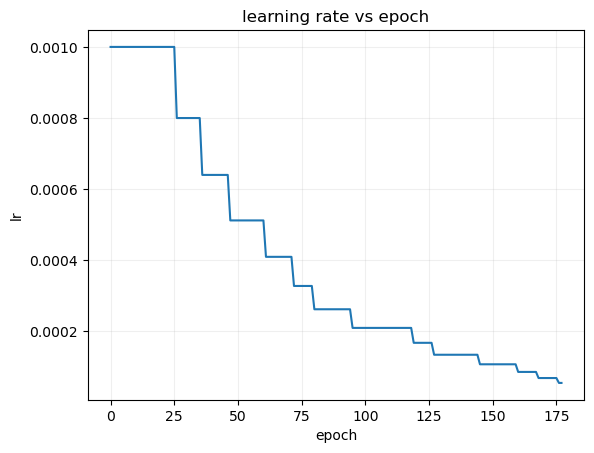

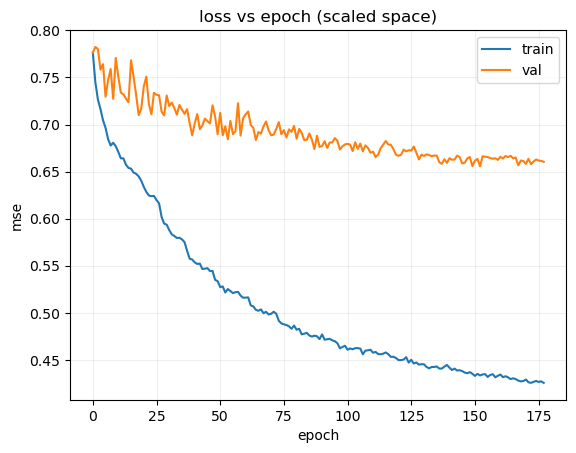

In [76]:
criterion = nn.MSELoss() #loss function
optimizer = torch.optim.Adam(model.parameters(), lr=LR) #optimizer : automatic step for parameters

scheduler = None
if USE_SCHEDULER:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=SCHED_FACTOR,
        patience=SCHED_PATIENCE,
        threshold=1e-6,
        min_lr=MIN_LR,
        verbose=True
    )

best_val = float("inf")
pat = PATIENCE
best_path = os.path.join(OUT_DIR, "best_model.pt") #path when we save our best model

def run_eval_loss(model, loader):
    model.eval() #switch the model into evaluation mode
    losses = []
    with torch.no_grad(): #stop the gradient calculation
        for xb, yb in loader: #for validation batches
            xb, yb = xb.to(DEVICE), yb.to(DEVICE) #send data to GPU or CPU
            pred = model(xb) #prediction forward pass
            loss = criterion(pred, yb) #MSE calculation
            losses.append(loss.item()) #.item() ==> scalar tensor into float
    return float(np.mean(losses)) if losses else float("inf")

lr_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(1, EPOCHS + 1):
    model.train() #training mode 
    train_losses = [] #batch train losses list

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad() #put to zero accumulated gradients
        pred = model(xb) #forward pass
        loss = criterion(pred, yb) #calculation MSE
        loss.backward() #back propagation
        optimizer.step() #new weights (from Adam and loss)

        train_losses.append(loss.item()) #stock float of the batch

    train_loss = float(np.mean(train_losses)) #mean loss on all the batches
    val_loss = run_eval_loss(model, val_loader) #mean loss on validation

    if scheduler is not None:
        scheduler.step(val_loss) #scheduler step based on val loss

    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    if epoch > 1:
        if val_loss < best_val - 1e-6: #minimal amelioration treshold
            best_val = val_loss
            pat = PATIENCE #patience to maximum
            torch.save(model.state_dict(), best_path) #new best model
        else:
            pat -= 1

        if pat <= 0:
            print("early stopping triggered.")
            break

    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:03d} | train {train_loss:.5f} | val {val_loss:.5f} | best {best_val:.5f} | patience {pat} | lr {current_lr:.6g}")

# reload best
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()
print("loaded best model from:", best_path)
print("best val loss (scaled space):", best_val)

# save logs
logs_path = os.path.join(OUT_DIR, "train_logs.csv")
pd.DataFrame({
    "epoch": np.arange(1, len(train_loss_history)+1),
    "train_loss": train_loss_history,
    "val_loss": val_loss_history,
    "lr": lr_history,
}).to_csv(logs_path, index=False)
print("saved logs to:", logs_path)

# plot lr
plt.figure()
plt.plot(lr_history)
plt.title("learning rate vs epoch")
plt.xlabel("epoch")
plt.ylabel("lr")
plt.grid(True, alpha=0.2)
plt.show()

# plot losses
plt.figure()
plt.plot(train_loss_history, label="train")
plt.plot(val_loss_history, label="val")
plt.title("loss vs epoch (scaled space)")
plt.xlabel("epoch")
plt.ylabel("mse")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

val loss (scaled space): 0.6556337375355803

val metrics (real units):
g  mae : 0.29013708233833313 rmse: 0.3766625821404128 mae/mean[%]: 22.917857812145222


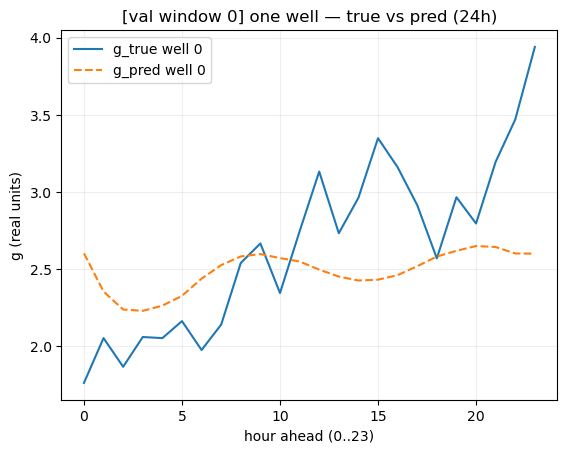

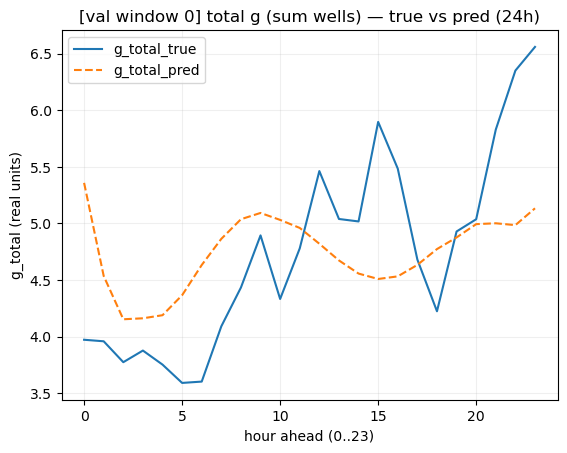

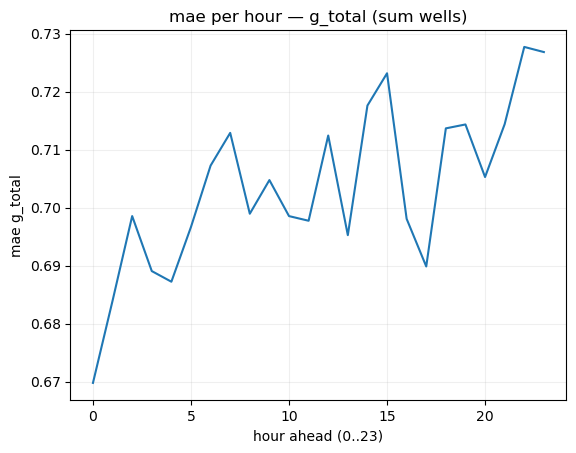

roughness g_total (true mean / pred mean): 0.6191813945770264 0.2494014948606491


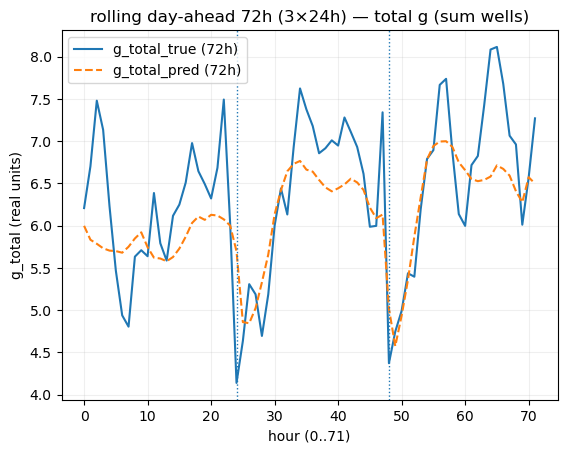

sum g_total over 72h (true / pred): 458.9764404296875 439.99627685546875


In [77]:
# predict val (scaled space)
preds_s = []
with torch.no_grad():
    for xb, _ in val_loader:
        xb = xb.to(DEVICE)
        preds_s.append(model(xb).cpu().numpy())
y_val_pred_s = np.vstack(preds_s)

# inverse scale to real units
y_val_true = scaler_y.inverse_transform(y_val_s)
y_val_pred = scaler_y.inverse_transform(y_val_pred_s)

print("val loss (scaled space):", best_val)

H = HORIZON_HOURS
G = meta["G"]  # number of wells

def split_g(y_flat):
    y_g = y_flat.reshape(-1, H, G)  # (N, 24, G)
    return y_g

g_true = split_g(y_val_true)
g_pred = split_g(y_val_pred)

# metrics (global)
g_mae = mean_absolute_error(g_true.reshape(-1), g_pred.reshape(-1))
g_rmse = rmse_flat(g_true.reshape(-1), g_pred.reshape(-1))
g_mae_pct = 100.0 * float(np.mean(np.abs(g_true - g_pred))) / (float(np.mean(np.abs(g_true))) + 1e-9)

print("\nval metrics (real units):")
print("g  mae :", g_mae, "rmse:", g_rmse, "mae/mean[%]:", g_mae_pct)

# totals (sum wells) on 24h
g_tot_true = np.sum(g_true, axis=2)  # (N, 24)
g_tot_pred = np.sum(g_pred, axis=2)  # (N, 24)

# plot pred vs true for 1 well (configurable)
WELL_ID = 0  # change this (0..G-1)
VAL_WIN_IDX = 0  # change this (0..N_val-1)

hours = np.arange(H)

plt.figure()
plt.plot(hours, g_true[VAL_WIN_IDX, :, WELL_ID], label=f"g_true well {WELL_ID}")
plt.plot(hours, g_pred[VAL_WIN_IDX, :, WELL_ID], "--", label=f"g_pred well {WELL_ID}")
plt.title(f"[val window {VAL_WIN_IDX}] one well — true vs pred (24h)")
plt.xlabel("hour ahead (0..23)")
plt.ylabel("g (real units)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# plot total g (sum wells) 24h
plt.figure()
plt.plot(hours, g_tot_true[VAL_WIN_IDX], label="g_total_true")
plt.plot(hours, g_tot_pred[VAL_WIN_IDX], "--", label="g_total_pred")
plt.title(f"[val window {VAL_WIN_IDX}] total g (sum wells) — true vs pred (24h)")
plt.xlabel("hour ahead (0..23)")
plt.ylabel("g_total (real units)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# mae per hour on total g
mae_g_tot_hour = np.mean(np.abs(g_tot_true - g_tot_pred), axis=0)  # (24,)

plt.figure()
plt.plot(mae_g_tot_hour)
plt.title("mae per hour — g_total (sum wells)")
plt.xlabel("hour ahead (0..23)")
plt.ylabel("mae g_total")
plt.grid(True, alpha=0.2)
plt.show()

# roughness on total g
def roughness_1d(x):  # x: (N, H)
    return np.mean(np.abs(x[:, 1:] - x[:, :-1]), axis=1)  # (N,)

r_g_true = roughness_1d(g_tot_true)
r_g_pred = roughness_1d(g_tot_pred)

print("roughness g_total (true mean / pred mean):", float(r_g_true.mean()), float(r_g_pred.mean()))
if r_g_pred.mean() > 1.5 * r_g_true.mean():
    print("[warn] g_total predictions look too oscillatory vs true (roughness too high).")

# =========================
# rolling 72h = 3 x 24h day-ahead on validation timeline (stride=24)
# =========================
# note: rolling uses raw timeline (df_g_all + cons_g_all), not window list
# we simulate operational day-ahead: t0, t0+24, t0+48

# build arrays for timeline access
Y_g_cols = meta["Y_g_cols"]
X_cols = meta["X_dyn_cols"]

ts_all = df_g_all["ts"].to_numpy()
X_timeline = cons_g_all[X_cols].to_numpy(dtype=np.float32)
Y_timeline = df_g_all[Y_g_cols].to_numpy(dtype=np.float32)

static_vec = static["static_vec"].astype(np.float32)

def build_x_for_t0(t0_idx):
    x_hist = X_timeline[t0_idx - HIST_HOURS:t0_idx, :]  # (72, d)
    x_flat = x_hist.reshape(-1)
    if USE_STATIC and static_vec.size > 0:
        x_flat = np.concatenate([x_flat, static_vec], axis=0)
    return x_flat.astype(np.float32)

def predict_24h_from_x(x_flat):
    x_s = scaler_X.transform(x_flat.reshape(1, -1)).astype(np.float32)
    xb = torch.from_numpy(x_s).float().to(DEVICE)
    with torch.no_grad():
        y_s = model(xb).cpu().numpy()
    y_real = scaler_y.inverse_transform(y_s)[0]  # (24*G,)
    return y_real.astype(np.float32).reshape(H, G)

def true_24h_from_t0(t0_idx):
    return Y_timeline[t0_idx:t0_idx+H, :].astype(np.float32)  # (24,G)

# choose a start time inside validation part
# we pick the first validation window start (win_ts[0]) as reference
t0_ts = win_ts[0]
t0_idx_candidates = np.where(ts_all == t0_ts)[0]
if len(t0_idx_candidates) == 0:
    raise ValueError("cannot find win_ts[0] inside df_g_all ts")
t0_start = int(t0_idx_candidates[0])

# safety: need enough history and 72h future
if t0_start - HIST_HOURS < 0 or t0_start + 72 > len(ts_all):
    raise ValueError("not enough history/future for rolling 72h at chosen t0_start")

g_true_72 = []
g_pred_72 = []
for k in range(3):
    t0 = t0_start + k * 24
    x_flat = build_x_for_t0(t0)
    g_pred_24 = predict_24h_from_x(x_flat)
    g_true_24 = true_24h_from_t0(t0)
    g_true_72.append(g_true_24)
    g_pred_72.append(g_pred_24)

g_true_72 = np.concatenate(g_true_72, axis=0)  # (72,G)
g_pred_72 = np.concatenate(g_pred_72, axis=0)  # (72,G)

g_tot_true_72 = np.sum(g_true_72, axis=1)  # (72,)
g_tot_pred_72 = np.sum(g_pred_72, axis=1)  # (72,)

hours_72 = np.arange(72)

plt.figure()
plt.plot(hours_72, g_tot_true_72, label="g_total_true (72h)")
plt.plot(hours_72, g_tot_pred_72, "--", label="g_total_pred (72h)")
plt.axvline(24, linestyle=":", linewidth=1)
plt.axvline(48, linestyle=":", linewidth=1)
plt.title("rolling day-ahead 72h (3×24h) — total g (sum wells)")
plt.xlabel("hour (0..71)")
plt.ylabel("g_total (real units)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

print("sum g_total over 72h (true / pred):", float(g_tot_true_72.sum()), float(g_tot_pred_72.sum()))

t0_start = 6576 → ts = 2024-10-01T00:00:00.000000000


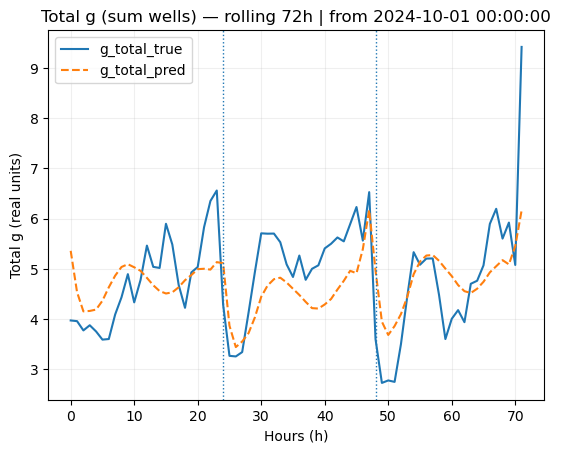

g_true_72 shape: (72, 4)
g_pred_72 shape: (72, 4)


In [78]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ── SEUL PARAMÈTRE À SYNCHRONISER entre les notebooks ────────────
ALIGN_TS = "2024-10-01 00:00:00"   # ← même date dans tous les notebooks
# ─────────────────────────────────────────────────────────────────

N_DAYS = 3
H      = HORIZON_HOURS   # 24
HIST   = HIST_HOURS      # 72
G      = meta["G"]       # nombre de wells

use_static = False

# ---------- helpers ----------
def build_X_for_t0_gaz(t0_idx, cons_g_all, static_vec, dyn_per_hour, HIST=72, use_static=False):
    x_hist = cons_g_all.iloc[t0_idx - HIST:t0_idx].drop(columns=["ts"], errors="ignore").to_numpy(dtype=np.float32)
    assert x_hist.shape[0] == HIST
    x_flat = x_hist.reshape(-1)
    if use_static:
        x_flat = np.concatenate([x_flat, static_vec.astype(np.float32)], axis=0)
    return x_flat.astype(np.float32)

def get_true_g_for_horizon(t0_idx, df_g_all, H=24):
    Y_g_cols = [c for c in df_g_all.columns if str(c).startswith("g_")]
    return df_g_all.iloc[t0_idx:t0_idx+H][Y_g_cols].to_numpy(dtype=np.float32)

def model_predict_24h_gaz(x_flat, model, scaler_X, scaler_y, device):
    x_s = scaler_X.transform(x_flat.reshape(1, -1)).astype(np.float32)
    xb  = torch.from_numpy(x_s).to(device)
    model.eval()
    with torch.no_grad():
        y_s = model(xb).cpu().numpy()
    return scaler_y.inverse_transform(y_s)[0].astype(np.float32)

# ---------- Trouve t0_start depuis ALIGN_TS ----------
ts_arr  = df_g_all["ts"].to_numpy()
target  = np.datetime64(pd.Timestamp(ALIGN_TS))
matches = np.where(ts_arr == target)[0]

if len(matches) == 0:
    print("Timestamps disponibles (5 autour du split):", ts_arr[6480:6485])
    raise ValueError(f"{ALIGN_TS} introuvable — change ALIGN_TS.")

t0_start = int(matches[0])
print(f"t0_start = {t0_start} → ts = {ts_arr[t0_start]}")

N_total = len(df_g_all)
assert t0_start - HIST >= 0,               "Pas assez d'historique avant t0_start."
assert t0_start + N_DAYS*H <= N_total,     "Pas assez de points futurs."

dyn_per_hour = int(meta["dyn_per_hour"])
static_vec   = np.zeros(0, dtype=np.float32)

# ---------- rolling prediction ----------
g_true_72, g_pred_72 = [], []
ts_72 = []

for day in range(N_DAYS):
    t0     = t0_start + day * H
    x_flat = build_X_for_t0_gaz(t0, cons_g_all, static_vec, dyn_per_hour, HIST=HIST, use_static=use_static)

    y_pred_flat = model_predict_24h_gaz(x_flat, model, scaler_X, scaler_y, DEVICE)
    g_pred_24   = y_pred_flat.reshape(H, G)
    g_true_24   = get_true_g_for_horizon(t0, df_g_all, H=H)

    g_true_72.append(g_true_24)
    g_pred_72.append(g_pred_24)
    ts_72.append(df_g_all.iloc[t0:t0+H]["ts"].to_numpy())

g_true_72 = np.concatenate(g_true_72, axis=0)
g_pred_72 = np.concatenate(g_pred_72, axis=0)
ts_72     = np.concatenate(ts_72,     axis=0)

g_tot_true_72 = np.sum(g_true_72, axis=1)
g_tot_pred_72 = np.sum(g_pred_72, axis=1)

x = np.arange(N_DAYS * H)

plt.figure()
plt.plot(x, g_tot_true_72, label="g_total_true")
plt.plot(x, g_tot_pred_72, "--", label="g_total_pred")
plt.axvline(24, linestyle=":", linewidth=1)
plt.axvline(48, linestyle=":", linewidth=1)
plt.title(f"Total g (sum wells) — rolling 72h | from {ALIGN_TS}")
plt.xlabel("Hours (h)")
plt.ylabel("Total g (real units)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

print("g_true_72 shape:", g_true_72.shape)
print("g_pred_72 shape:", g_pred_72.shape)

t0_start = 7320 | ts = 2024-11-01 00:00:00


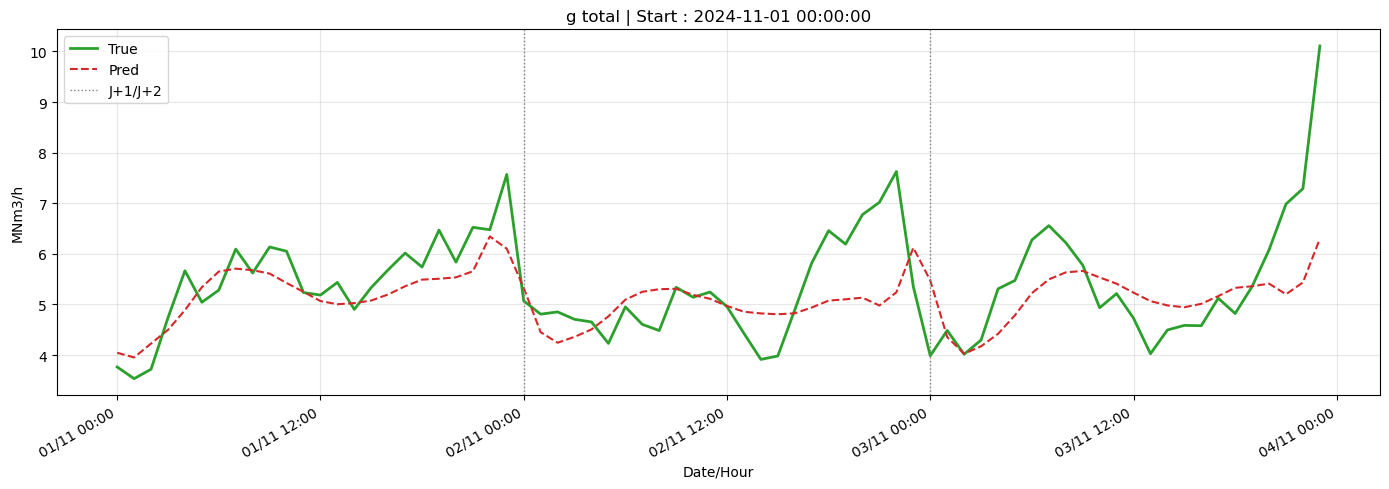

Figure sauvegardée dans : ./runs_mlp_gas_only\rolling_72h_g_total_gaz_only.png
g_true_72 shape : (72, 4)
g_pred_72 shape : (72, 4)


In [79]:
# ============================================================
# CELL — Plot rolling 72h (3 jours) | GAZ ONLY
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch

ALIGN_TS = "2024-11-01 00:00:00"   # même date que dans les autres notebooks
N_DAYS   = 3

H    = HORIZON_HOURS   # 24
HIST = HIST_HOURS      # 72
G    = meta["G"]       # nombre de wells

use_static = False

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def build_X_for_t0_gaz(t0_idx, cons_g_all, static_vec, HIST=72, use_static=False):
    x_hist = (
        cons_g_all.iloc[t0_idx - HIST:t0_idx]
        .drop(columns=["ts"], errors="ignore")
        .to_numpy(dtype=np.float32)
    )
    assert x_hist.shape[0] == HIST, f"Historique invalide: {x_hist.shape}"
    
    x_flat = x_hist.reshape(-1)
    
    if use_static:
        x_flat = np.concatenate([x_flat, static_vec.astype(np.float32)], axis=0)
    
    return x_flat.astype(np.float32)

def get_true_g_for_horizon(t0_idx, df_g_all, H=24):
    Y_g_cols = [c for c in df_g_all.columns if str(c).startswith("g_")]
    return df_g_all.iloc[t0_idx:t0_idx+H][Y_g_cols].to_numpy(dtype=np.float32)

def model_predict_24h_gaz(x_flat, model, scaler_X, scaler_y, device):
    x_s = scaler_X.transform(x_flat.reshape(1, -1)).astype(np.float32)
    xb  = torch.from_numpy(x_s).to(device)

    model.eval()
    with torch.no_grad():
        y_s = model(xb).cpu().numpy()

    return scaler_y.inverse_transform(y_s)[0].astype(np.float32)

# ------------------------------------------------------------
# Recherche du timestamp de départ
# ------------------------------------------------------------
target = pd.Timestamp(ALIGN_TS)
ts_arr = pd.to_datetime(df_g_all["ts"]).to_numpy()

matches = np.where(ts_arr == np.datetime64(target))[0]
if len(matches) == 0:
    raise ValueError(f"{ALIGN_TS} introuvable dans df_g_all['ts'].")

t0_start = int(matches[0])

N_total = len(df_g_all)
assert t0_start - HIST >= 0, "Pas assez d'historique avant ALIGN_TS."
assert t0_start + N_DAYS * H <= N_total, "Pas assez de points après ALIGN_TS."

print(f"t0_start = {t0_start} | ts = {df_g_all.iloc[t0_start]['ts']}")

# ------------------------------------------------------------
# Rolling prediction sur 3 jours
# ------------------------------------------------------------
static_vec = np.zeros(0, dtype=np.float32)

g_true_72 = []
g_pred_72 = []
ts_72     = []

for day in range(N_DAYS):
    t0 = t0_start + day * H

    x_flat = build_X_for_t0_gaz(
        t0_idx=t0,
        cons_g_all=cons_g_all,
        static_vec=static_vec,
        HIST=HIST,
        use_static=use_static
    )

    y_pred_flat = model_predict_24h_gaz(x_flat, model, scaler_X, scaler_y, DEVICE)

    g_pred_24 = y_pred_flat.reshape(H, G)
    g_true_24 = get_true_g_for_horizon(t0, df_g_all, H=H)

    g_true_72.append(g_true_24)
    g_pred_72.append(g_pred_24)
    ts_72.append(pd.to_datetime(df_g_all.iloc[t0:t0+H]["ts"]).to_numpy())

g_true_72 = np.concatenate(g_true_72, axis=0)   # shape: (72, G)
g_pred_72 = np.concatenate(g_pred_72, axis=0)   # shape: (72, G)
ts_72     = np.concatenate(ts_72, axis=0)       # shape: (72,)

# Somme totale sur tous les wells
g_tot_true_72 = np.sum(g_true_72, axis=1)
g_tot_pred_72 = np.sum(g_pred_72, axis=1)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ts_72, g_tot_true_72, label="True", lw=2,   color="#2ca02c")
ax.plot(ts_72, g_tot_pred_72, label="Pred", lw=1.5, color="#d62728", ls="--")

# Lignes verticales jour +1 et jour +2
for d in [1, 2]:
    ax.axvline(ts_72[d * H], color="gray", lw=1, ls=":", label="J+1/J+2" if d == 1 else "")

ax.set_ylabel("MNm3/h")
ax.set_xlabel("Date/Hour")
ax.set_title(f"g total | Start : {ALIGN_TS}")
ax.legend()
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:00"))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()

save_path = os.path.join(OUT_DIR, "rolling_72h_g_total_gaz_only.png")
fig.savefig(save_path, dpi=130, bbox_inches="tight")
plt.show()

print("Figure sauvegardée dans :", save_path)
print("g_true_72 shape :", g_true_72.shape)
print("g_pred_72 shape :", g_pred_72.shape)

=== GAZ ONLY | Global metrics on validation ===
MAE            : 0.703503
RMSE           : 0.937170
MAE/mean       : 0.138924
Roughness err  : 0.374997
Roughness true : 0.633130
Roughness pred : 0.258134


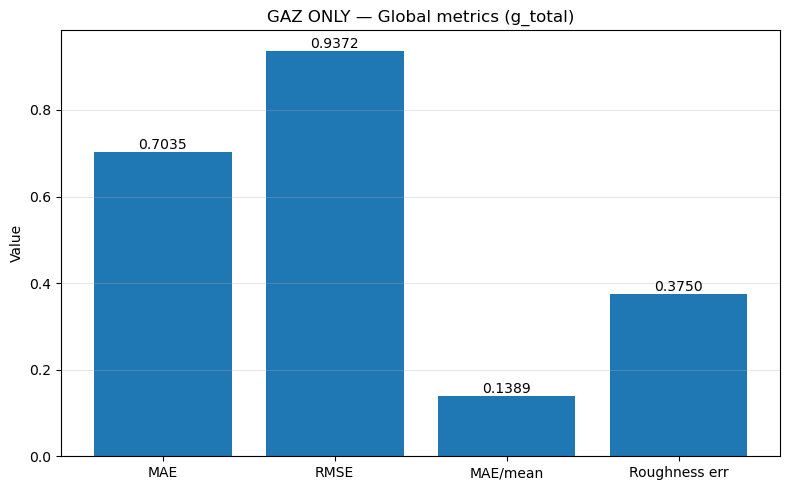

Figure saved to: ./runs_mlp_gas_only\global_metrics_gaz_only.png


In [80]:
# ============================================================
# CELL — Global metrics plot | GAZ ONLY
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def roughness(x):
    x = np.asarray(x).reshape(-1)
    if len(x) < 2:
        return 0.0
    return float(np.mean(np.abs(np.diff(x))))

# ------------------------------------------------------------
# Prédictions globales sur le set de validation
# ------------------------------------------------------------
model.eval()
with torch.no_grad():
    pred_s = model(torch.from_numpy(X_val_s).to(DEVICE)).cpu().numpy()

# retour échelle réelle
pred_real = scaler_y.inverse_transform(pred_s)     # shape: (N, 24*G)
true_real = y_val.copy() if 'y_val' in globals() else scaler_y.inverse_transform(y_val_s)

# reshape en (N, H, G)
G = meta["G"]
H = HORIZON_HOURS

pred_real_3d = pred_real.reshape(-1, H, G)
true_real_3d = true_real.reshape(-1, H, G)

# total gaz
g_pred_total = pred_real_3d.sum(axis=2).reshape(-1)
g_true_total = true_real_3d.sum(axis=2).reshape(-1)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
metric_mae       = mae(g_true_total, g_pred_total)
metric_rmse      = rmse(g_true_total, g_pred_total)
metric_mae_mean  = metric_mae / (np.mean(np.abs(g_true_total)) + 1e-12)
rough_true       = roughness(g_true_total)
rough_pred       = roughness(g_pred_total)
metric_roughness = abs(rough_pred - rough_true)

metrics = {
    "MAE": metric_mae,
    "RMSE": metric_rmse,
    "MAE/mean": metric_mae_mean,
    "Roughness err": metric_roughness
}

print("=== GAZ ONLY | Global metrics on validation ===")
for k, v in metrics.items():
    print(f"{k:<15}: {v:.6f}")
print(f"{'Roughness true':<15}: {rough_true:.6f}")
print(f"{'Roughness pred':<15}: {rough_pred:.6f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
names  = list(metrics.keys())
values = list(metrics.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, values)

ax.set_title("GAZ ONLY — Global metrics (g_total)")
ax.set_ylabel("Value")
ax.grid(True, axis="y", alpha=0.3)

for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.4f}",
            ha="center", va="bottom", fontsize=10)

fig.tight_layout()

save_path = os.path.join(OUT_DIR, "global_metrics_gaz_only.png")
fig.savefig(save_path, dpi=140, bbox_inches="tight")
plt.show()

print("Figure saved to:", save_path)